In [7]:
# Install required libraries inside Jupyter environment
# pandas → for handling CSV files
# scikit-learn → for machine learning
# nltk → for sentiment analysis (VADER)
!pip install pandas scikit-learn nltk
!pip install matplotlib seaborn
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [8]:
# Import pandas to read and manipulate CSV data
import pandas as pd  

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split  

# Converts text data into numerical vectors (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer  

# Logistic Regression model for classification (positive/negative)
from sklearn.linear_model import LogisticRegression  

# Used to calculate accuracy of model predictions
from sklearn.metrics import accuracy_score  

# Import nltk (Natural Language Toolkit)
import nltk

import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # better visualizations

# Import VADER sentiment analyzer (designed for social media text)
from nltk.sentiment import SentimentIntensityAnalyzer  

# Download VADER lexicon (dictionary of words with sentiment scores)
# This runs only once and stores data locally
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/pict/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [9]:
# Load first dataset (data science tweets)
df1 = pd.read_csv("data_science.csv")

# Load second dataset (data analysis tweets)
df2 = pd.read_csv("data_analysis.csv")

# Load third dataset (data visualization tweets)
df3 = pd.read_csv("data_visualization.csv")

# Combine all three datasets into one dataframe
# ignore_index=True → resets row numbering
df = pd.concat([df1, df2, df3], ignore_index=True)

# Display first 5 rows to understand structure
df.head()

/tmp/ipykernel_6919/1289676060.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("data_science.csv")
/tmp/ipykernel_6919/1289676060.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("data_analysis.csv")
/tmp/ipykernel_6919/1289676060.py:8: DtypeWarning: Columns (22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("data_visualization.csv")


,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1406400408545804288,1406400396264943616,2021-06-20 05:26:01 IST,2021-06-20,05:26:01,530,1113747629282930688,ballouxfrancois,Prof Francois Balloux,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,1406390341176016897,1406390341176016897,2021-06-20 04:46:01 IST,2021-06-20,04:46:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1406386311481774083,1406386311481774083,2021-06-20 04:30:00 IST,2021-06-20,04:30:00,530,19402238,sciencenews,Science News,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1406383545153638402,1406383545153638402,2021-06-20 04:19:01 IST,2021-06-20,04:19:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1406358632648818689,1406358632648818689,2021-06-20 02:40:01 IST,2021-06-20,02:40:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [33]:
# ================= DATA PREPROCESSING =================

import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags symbol
    text = re.sub(r'#', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra spaces
    text = text.strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply preprocessing
df["clean_tweet"] = df["tweet"].apply(clean_text)

# Use cleaned text for model
X = vectorizer.fit_transform(df["clean_tweet"])

[nltk_data] Downloading package stopwords to /home/pict/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Print all column names to find where tweet text is stored
print(df.columns)

Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')


In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create analyzer
sia = SentimentIntensityAnalyzer()

# Define function (IMPORTANT)
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

# Apply compound score
df["compound"] = df["tweet"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

# Index for plotting
df["index"] = range(len(df))

# Apply sentiment
df["sentiment"] = df["tweet"].apply(get_sentiment)

# Display
df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest,compound,index,sentiment
0,1406400408545804288,1406400396264943616,2021-06-20 05:26:01 IST,2021-06-20,05:26:01,530,1113747629282930688,ballouxfrancois,Prof Francois Balloux,NaN,...,NaN,NaN,[],NaN,NaN,NaN,NaN,-0.4592,0,negative
1,1406390341176016897,1406390341176016897,2021-06-20 04:46:01 IST,2021-06-20,04:46:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,[],NaN,NaN,NaN,NaN,0.0000,1,neutral
2,1406386311481774083,1406386311481774083,2021-06-20 04:30:00 IST,2021-06-20,04:30:00,530,19402238,sciencenews,Science News,NaN,...,NaN,NaN,[],NaN,NaN,NaN,NaN,0.0000,2,neutral
3,1406383545153638402,1406383545153638402,2021-06-20 04:19:01 IST,2021-06-20,04:19:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,[],NaN,NaN,NaN,NaN,0.7430,3,positive
4,1406358632648818689,1406358632648818689,2021-06-20 02:40:01 IST,2021-06-20,02:40:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,[],NaN,NaN,NaN,NaN,0.4019,4,positive


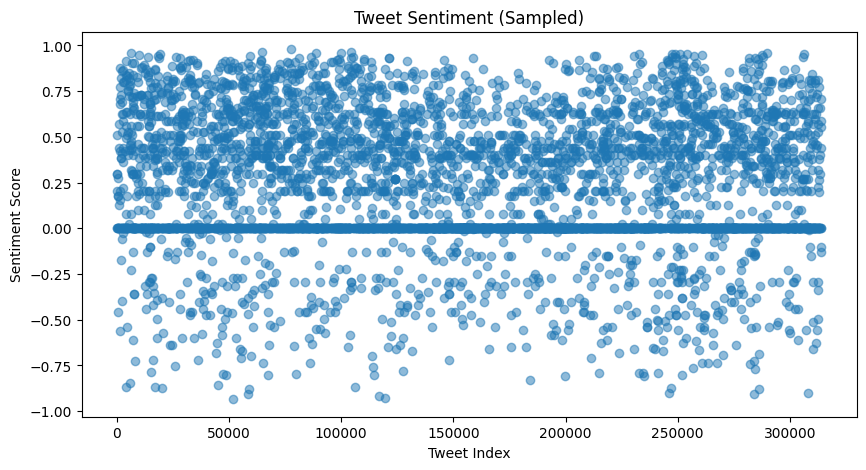

In [27]:
sample_df = df.sample(5000)

plt.figure(figsize=(10,5))
plt.scatter(sample_df["index"], sample_df["compound"], alpha=0.5)

plt.title("Tweet Sentiment (Sampled)")
plt.xlabel("Tweet Index")
plt.ylabel("Sentiment Score")

plt.show()

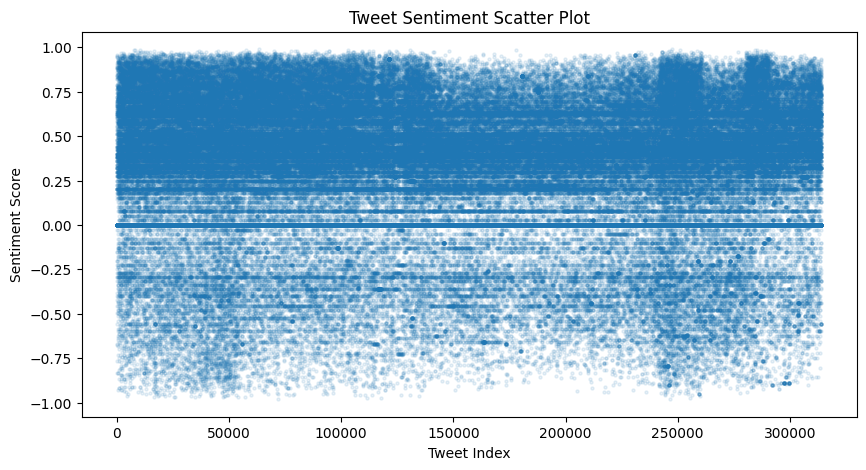

In [31]:
plt.figure(figsize=(10,5))

plt.scatter(df["index"], df["compound"], alpha=0.1, s=5)

plt.title("Tweet Sentiment Scatter Plot")
plt.xlabel("Tweet Index")
plt.ylabel("Sentiment Score")

plt.show()

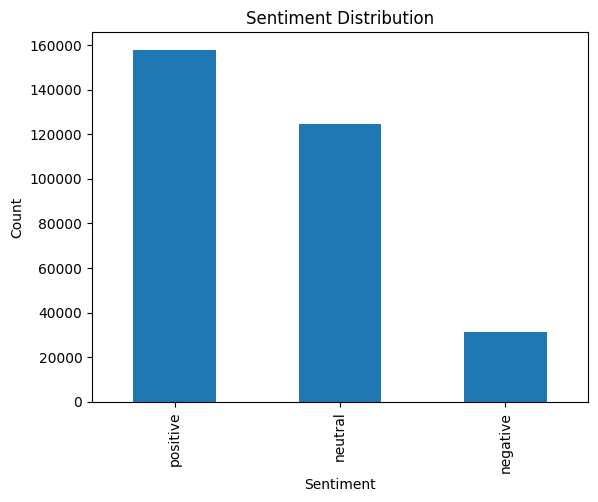

In [13]:

# Count number of positive/negative tweets
df["sentiment"].value_counts().plot(kind='bar')

# Add title and labels
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Show plot
plt.show()

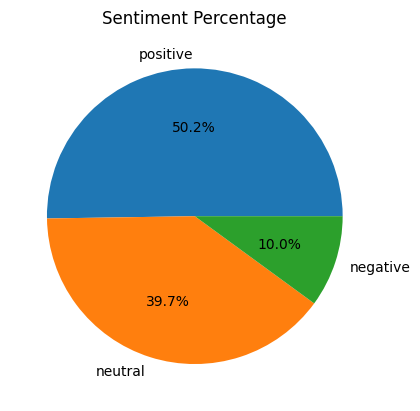

In [14]:
# Pie chart of sentiment distribution
df["sentiment"].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Percentage")
plt.ylabel("")  # removes extra label

plt.show()

In [15]:
print(df["sentiment"].value_counts())

sentiment
positive    157815
neutral     124741
negative     31536
Name: count, dtype: int64


In [16]:
# Initialize CountVectorizer (Bag of Words model)
vectorizer = CountVectorizer()

# Convert all tweet text into numerical feature vectors
# fit_transform → learns vocabulary + converts text to numbers
X = vectorizer.fit_transform(df["tweet"])

# Store target labels (positive/negative)
y = df["sentiment"]

In [17]:
# Split dataset into training and testing sets
# test_size=0.2 → 20% data for testing, 80% for training
# random_state ensures same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
# Train model using training data
# Model learns relationship between text and sentiment
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
# Predict sentiment for test data
y_pred = model.predict(X_test)

In [20]:
# Calculate accuracy (percentage of correct predictions)
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)

Accuracy: 0.9395246661042042


In [25]:
# Example custom tweet
                                                                              

# Convert this text into numerical vector using same vectorizer
sample_vec = vectorizer.transform(sample)

# Predict sentiment
prediction = model.predict(sample_vec)

# Print result
print("Prediction:", prediction)

Prediction: ['negative']


In [32]:
samples = [
    "I love this",
    "This is amazing",
    "I hate this ",
    "This is terrible and frustrating",
        "There is a tree"
]

for s in samples:
    vec = vectorizer.transform([s])
    print(s, "->", model.predict(vec))

I love this -> ['positive']
This is amazing -> ['positive']
I hate this  -> ['negative']
This is terrible and frustrating -> ['negative']
There is a tree -> ['neutral']


Accuracy: 0.9395246661042042

Precision: 0.9403541314217445
Recall: 0.9395246661042042
F1 Score: 0.9397854714945899

Classification Report:

              precision    recall  f1-score   support

    negative       0.80      0.83      0.82      6371
     neutral       0.94      0.96      0.95     25008
    positive       0.97      0.94      0.95     31440

    accuracy                           0.94     62819
   macro avg       0.90      0.91      0.91     62819
weighted avg       0.94      0.94      0.94     62819


Confusion Matrix:
 [[ 5306   533   532]
 [  377 24118   513]
 [  930   914 29596]]


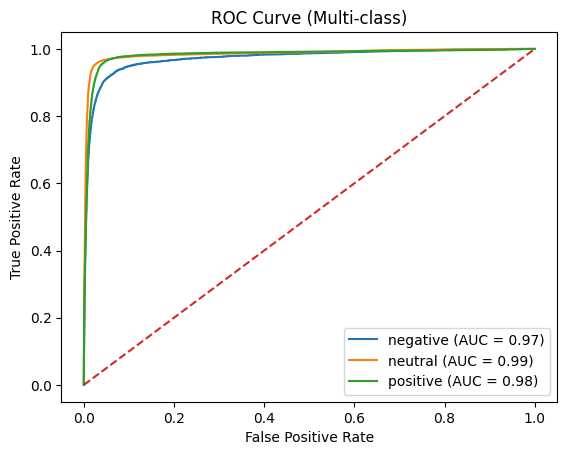

In [34]:
# ================= COMPLETE EVALUATION =================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# ---------------- BASIC METRICS ----------------
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nPrecision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# ---------------- DETAILED REPORT ----------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ---------------- ROC & AUC ----------------

# Convert labels to binary format (for multi-class support)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probability scores
if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)

    plt.figure()

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multi-class)")
    plt.legend()
    plt.show()

else:
    print("\nModel does not support probability predictions (ROC not available)")